# Drug Response Prediction with Predicted Profiles

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,ttest_ind
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
# Get the project root directory
from pathlib import Path
import sys

project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [3]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_04_DIR)
figures_dir = str(config.FIGURES_04_DIR)

In [4]:
# Prediction evaluation function. Either pearsonr or spearmanr
evaluation_function = pearsonr

In [5]:
# Color palettes
pre_post_lfc_palette = {
    'Grey': '#808080',       # Standard grey
    'Red': '#FF0000',        # Bright red
    'Dark Red': '#8B0000'    # Dark red
}
pre_post_lfc_palette = list(pre_post_lfc_palette.values())
    

In [6]:
def compute_pearson(predictions, groupby=['model', 'test_set', 'train_set', 'split']):

    pearson_results = predictions.groupby(groupby).apply(
        lambda group: evaluation_function(group['true'], group['pred'])[0]
    ).fillna(0)
    pearson_p_value_results = predictions.groupby(groupby).apply(
        lambda group: evaluation_function(group['true'], group['pred'])[1]
    ).fillna(1)

    pearson_results = pd.merge(pearson_results.reset_index(), pearson_p_value_results.reset_index(), on=groupby).rename(columns={'0_x': 'pearson', '0_y': 'p-value'})

    pearson_results = pearson_results.reset_index(drop=True).replace({'post_treatment': 'Post', 'pre_treatment': 'Pre'}).replace({'observed':'Measured',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized',
                                                                                                                            'CPA_predicted':'CPA',
                                                                                                                            'GEARS_predicted':'GEARS',
                                                                                                                            'scFoundation_predicted':'scFoundation',
                                                                                                                            'no_effect': 'No effect',
                                                                                                                            'average_effect': 'Average effect'})

    from statsmodels.stats.multitest import multipletests

    pearson_results['adjusted_p'] = multipletests(pearson_results['p-value'], alpha=0.05, method='fdr_bh')[1]
    pearson_results['sig'] = np.where(pearson_results['adjusted_p'] < 0.05, '*', '')

    if 'test_set' in groupby:
        pearson_results['test_set'] = pd.Categorical(pearson_results['test_set'], categories=['Measured','CPA', 'GEARS','GEARS\nOptimized','scFoundation', 'Average effect', 'No effect', 'GEARS\nEnd-to-End'], ordered=True)

    return pearson_results


def compute_mse(predictions, groupby=['model', 'test_set', 'train_set', 'split']):

    mse_results = predictions.groupby(groupby).apply(
        lambda group: mean_squared_error(group['true'], group['pred']))

    mse_results = mse_results.reset_index().replace({'post_treatment': 'Post', 'pre_treatment': 'Pre'}).replace({'observed':'Measured',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized',
                                                                                                                            'CPA_predicted':'CPA',
                                                                                                                            'GEARS_predicted':'GEARS',
                                                                                                                            'scFoundation_predicted':'scFoundation',
                                                                                                                            'no_effect': 'No effect',
                                                                                                                            'average_effect': 'Average effect'})

    mse_results = mse_results.rename(columns={0:'mse'})                                                                                                                  

    if 'test_set' in groupby:
        mse_results['test_set'] = pd.Categorical(mse_results['test_set'], categories=['Measured','CPA', 'GEARS','GEARS\nOptimized','scFoundation', 'Average effect', 'No effect', 'GEARS\nEnd-to-End'], ordered=True)

    return mse_results

In [7]:
predictions_AUC = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_predictions_CV_twostep_AUC.csv'), index_col=0).reset_index().drop_duplicates().set_index('index')
selftrained_predictions_AUC = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_predictions_selftrained_CV_twostep_AUC.csv'), index_col=0).reset_index().drop_duplicates().set_index('index')

In [8]:
end_to_end_predictions  = []
for cl in ['mcf7', 'a549', 'k562']:
    outcome_path = os.path.join(data_dir, f'GEARS_end_to_end/sciplex{cl}')
    subfolders = [ f.path for f in os.scandir(outcome_path) if f.is_dir() ]
    newest_subfolders = [x for x in subfolders if '2025-06-20' in x]
    print(subfolders)
    for i in range(1, 6):
        outcomes = pd.read_csv(os.path.join(outcome_path, newest_subfolders[0], f'raw_y_pred_no_pretrain_fold{i}_1_sciplex{cl}.csv'))
        outcomes = outcomes.assign(cell_line=cl).assign(split=i)
        end_to_end_predictions.append(outcomes)

end_to_end_predictions = pd.concat(end_to_end_predictions, ignore_index=True).assign(test_set='GEARS\nEnd-to-End',train_set='observed', model='Embedding').rename(columns={'truth':'true'})

sciplex_pearson_results = compute_pearson(predictions_AUC)
sciplex_mse_results = compute_mse(predictions_AUC)
selftrained_sciplex_pearson_results = compute_pearson(selftrained_predictions_AUC)
selftrained_sciplex_mse_results = compute_mse(selftrained_predictions_AUC)
end_to_end_pearson = compute_pearson(end_to_end_predictions)
end_to_end_mse = compute_mse(end_to_end_predictions)

sciplex_pearson_results = pd.concat([sciplex_pearson_results.assign(trained_on='Measured'),selftrained_sciplex_pearson_results.assign(trained_on='Predicted'), end_to_end_pearson.assign(trained_on='End-to-end')], ignore_index=True)
sciplex_mse_results = pd.concat([sciplex_mse_results.assign(trained_on='Measured'),selftrained_sciplex_mse_results.assign(trained_on='Predicted'), end_to_end_mse.assign(trained_on='End-to-end')], ignore_index=True)

['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexmcf7\\2025-06-20_09-58-14']
['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexa549\\2025-06-20_09-54-17']
['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexk562\\2025-06-20_09-54-16']


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[0]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_results = predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[1]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:6: 

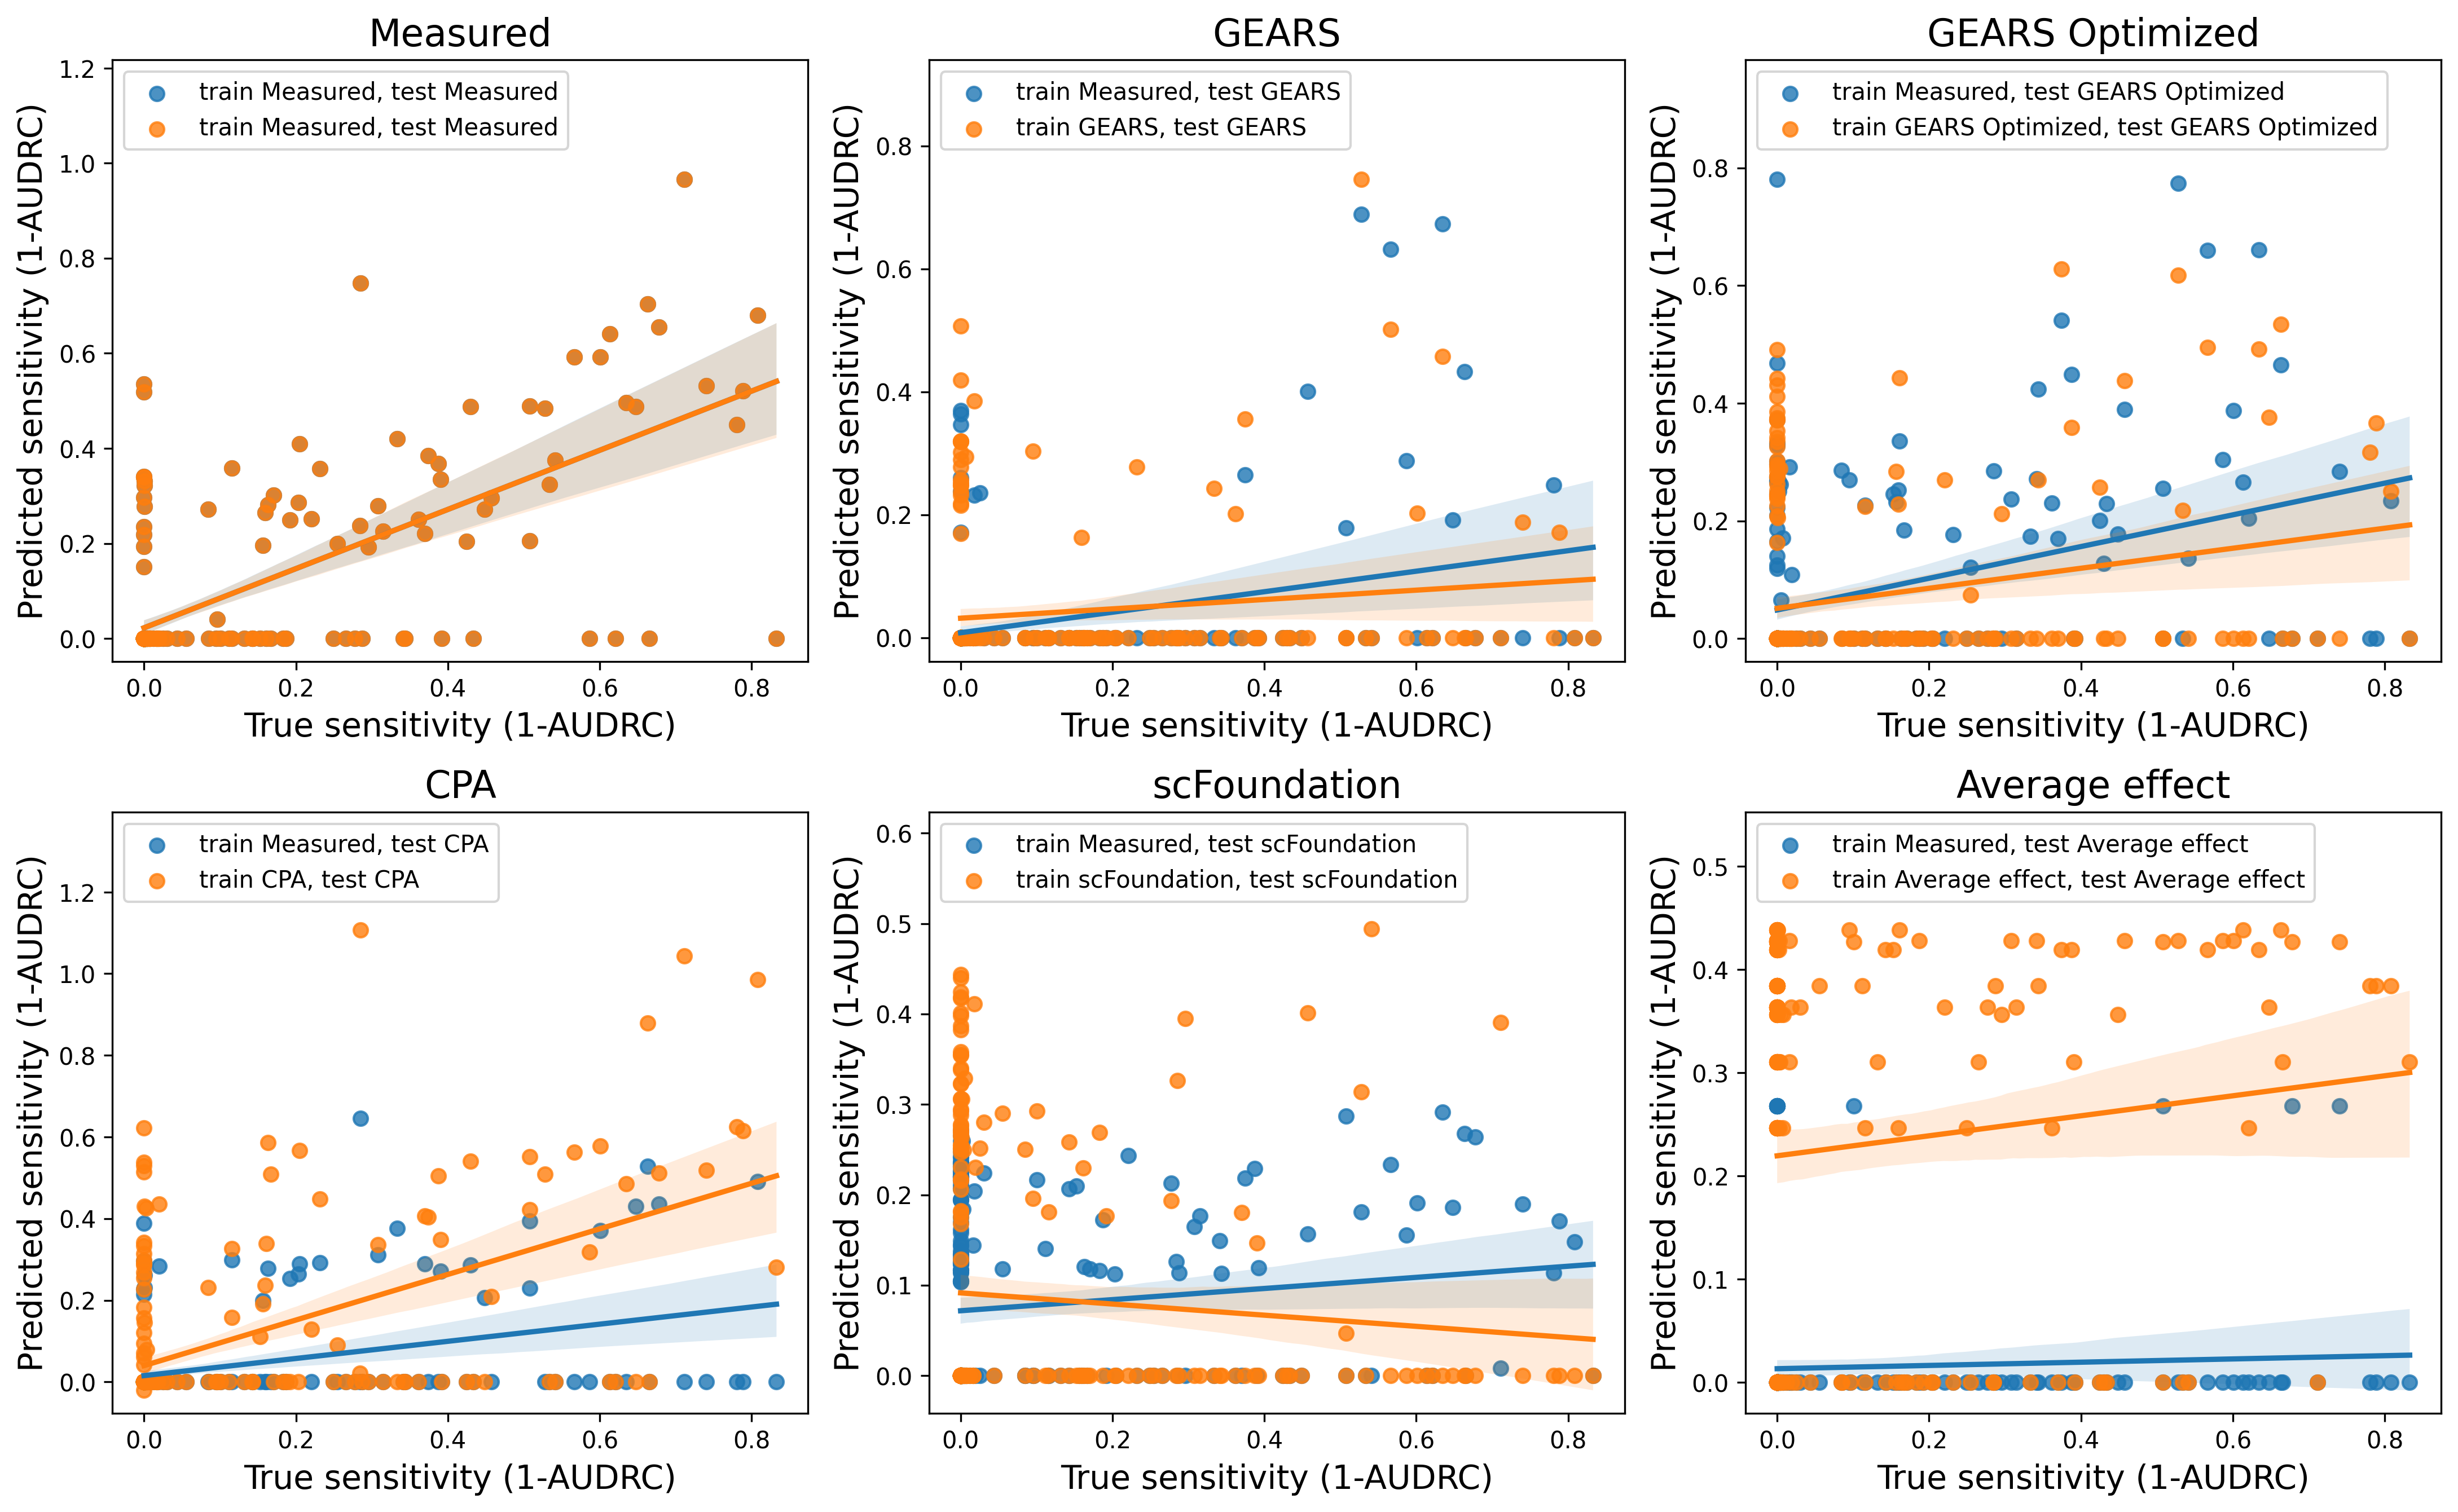

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unique training sets
# train_sets = selftrained_predictions_AUC['train_set'].unique().tolist()
train_sets = ['observed','GEARS', 'GEARS_noreg', 'CPA', 'scFoundation', 'Average effect']


# Mapping for display names
mapping = {
    'observed': 'Measured',
    'baseline': 'Average effect',
    'GEARS_noreg': 'GEARS Optimized'
}

# Create figure and axes
fig, axes = plt.subplots(3, 3, figsize=(15, 13), dpi=300)
axes = axes.flatten()
# If there is only one subplot, make axes a list for consistent indexing
if len(train_sets) == 1:
    axes = [axes]

for i, m in enumerate(train_sets):
    ax = axes[i]
    name = mapping.get(m, m)
    sns.regplot(
        data=predictions_AUC.query(f'test_set == "{m}" and train_set == "observed" and model == "LFC"'),
        x='true', y='pred', label=f'train Measured, test {name}', ax=ax
    )

    sns.regplot(
        data=selftrained_predictions_AUC.query(f'test_set == "{m}" and train_set == "{m}" and model == "LFC"'),
        x='true', y='pred', label=f'train {name}, test {name}', ax=ax
    )
 

    # Adjust ylim (+0.5 to the current max)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax *1.2)

    # Style
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlabel('True sensitivity (1-AUDRC)', fontsize=14)
    ax.set_ylabel('Predicted sensitivity (1-AUDRC)', fontsize=14)
    ax.set_title(name, fontsize=16)

# Hide unused subplot (8th cell)
if len(train_sets) < len(axes):
    for j in range(len(train_sets), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'regression_plots.pdf'), bbox_inches='tight')


In [10]:
def _baseline_means(results, metric):
    mask = (
        (results['trained_on'] == 'Measured')
        & (results['test_set'] == 'Measured')
        & (results['model'].isin(['Pre', 'Post', 'LFC']))
    )
    subset = results.loc[mask]
    return (
        subset.loc[subset['model'] == 'Pre', metric].mean(),
        subset.loc[subset['model'] == 'Post', metric].mean(),
        subset.loc[subset['model'] == 'LFC', metric].mean(),
    )


def _prepare_box_frames(pearson_results):
    box_data = pearson_results[~pearson_results['test_set'].isin(['GEARS\nEnd-to-End'])].copy()
    box_data = box_data[
        ~(
            ((box_data['test_set'] == 'No effect') | (box_data['train_set'] == 'No effect'))
            & (box_data['model'] == 'LFC')
        )
    ].copy()

    box0_data = box_data[
        (box_data['trained_on'] == 'Measured') & (box_data['test_set'].isin(['Measured']))
    ].copy()
    box2_data = box_data[
        (box_data['trained_on'] == 'Predicted') & (box_data['test_set'] != 'Measured')
    ].copy()

    box0_data['test_set'] = pd.Categorical(
        box0_data['test_set'], categories=['Measured'], ordered=True
    )
    box0_data['model'] = pd.Categorical(
        box0_data['model'], categories=['Pre', 'Post', 'LFC'], ordered=True
    )
    box2_data['test_set'] = pd.Categorical(
        box2_data['test_set'],
        categories=['CPA', 'GEARS', 'scFoundation', 'Average effect', 'No effect'],
        ordered=True,
    )
    box2_data['model'] = pd.Categorical(
        box2_data['model'], categories=['Post', 'LFC'], ordered=True
    )
    return box0_data, box2_data


def _drug_response_legend_handles(include_embedding=False):
    from matplotlib.patches import Patch

    handles = [
        Patch(facecolor=pre_post_lfc_palette[0], edgecolor='black', label='Pre'),
        Patch(facecolor=pre_post_lfc_palette[1], edgecolor='black', label='Post'),
        Patch(facecolor=pre_post_lfc_palette[2], edgecolor='black', label='LFC'),
    ]
    labels = ['Pre', 'Post', 'LFC']
    if include_embedding:
        handles.append(Patch(facecolor='black', edgecolor='black', label='Embedding'))
        labels.append('Embedding')
    return handles, labels


def _add_figure_legend(fig, include_embedding=False):
    handles, labels = _drug_response_legend_handles(include_embedding=include_embedding)
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(0.8,0.9),
        fontsize=14,
        frameon=False,
    )


def _add_boxplot_scatter_overlay(ax, data, metric, test_categories, model_categories, palette):
    x_locs = {cat: i for i, cat in enumerate(test_categories)}
    n_models = len(model_categories)
    box_width = 0.6

    offset_lookup = {
        model: (idx - (n_models - 1) / 2) * (box_width / n_models)
        for idx, model in enumerate(model_categories)
    }

    for test in test_categories:
        for j, model in enumerate(model_categories):
            group = data[(data['test_set'] == test) & (data['model'] == model)]
            if group.shape[0] == 0:
                continue
            x_center = x_locs[test] + offset_lookup[model]
            y = group[metric].values
            if len(y) == 1:
                x_vals = [x_center]
            else:
                x_span = (box_width / n_models) * 0.25
                x_vals = np.linspace(x_center - x_span / 2, x_center + x_span / 2, len(y))
            ax.scatter(
                x_vals,
                y,
                s=60,
                color=palette[j],
                edgecolor='black',
                linewidth=0.5,
                alpha=0.6,
                zorder=4,
                label=None,
            )


def _plot_box_panel(
    ax,
    data,
    metric,
    model_order,
    panel_idx,
    plot_legend,
    pre_obs=None,
    post_obs=None,
    lfc_obs=None,
    add_measured_lines=False,
    grid_lines_y=None,
    measured_lines_y=None,
    measured_lines_colors=None,
):
    palette = (
        [pre_post_lfc_palette[1], pre_post_lfc_palette[2]]
        if panel_idx > 0
        else [pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]]
    )
    test_categories = list(data['test_set'].cat.categories)
    model_categories = list(data['model'].cat.categories)

    sns.boxplot(
        data=data,
        x='test_set',
        hue='model',
        y=metric,
        palette=palette,
        width=0.65,
        ax=ax,
    )
    _add_boxplot_scatter_overlay(ax, data, metric, test_categories, model_categories, palette)

    if grid_lines_y is not None:
        for y in grid_lines_y:
            ax.axhline(y=y, color='lightgrey', linewidth=1, linestyle='-', alpha=0.7, zorder=0)
    else:
        ax.yaxis.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)

    # if measured_lines_y is not None and measured_lines_colors is not None:
    #     for y, color in zip(measured_lines_y, measured_lines_colors):
    #         ax.axhline(y=y, color=color, linestyle='-', linewidth=2, zorder=2)
    # elif add_measured_lines and pre_obs is not None and post_obs is not None and lfc_obs is not None:
    #     pre_color = pre_post_lfc_palette[0]
    #     post_color = pre_post_lfc_palette[1]
    #     lfc_color = pre_post_lfc_palette[2]
    #     if panel_idx == 0:
    #         ax.axhline(y=pre_obs, color=pre_color, linestyle='-', linewidth=2, zorder=2)
    #         ax.axhline(y=post_obs, color=post_color, linestyle='-', linewidth=2, zorder=2)
    #         ax.axhline(y=lfc_obs, color=lfc_color, linestyle='-', linewidth=2, zorder=2)

    sns.despine(ax=ax, offset=10, trim=False)
    ax.set_xlabel('')
    ax.xaxis.label.set_visible(False)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=22, rotation=45)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=22,
        rotation=45,
        ha='right',
        rotation_mode='anchor',
    )
    ax.yaxis.set_tick_params(labelsize=16)

    if hasattr(ax, 'legend_') and ax.legend_ is not None:
        ax.legend_.remove()


def _metric_ylabel(metric):
    if metric == 'pearson':
        return r'Pearson r  $\rightarrow$'
    if metric == 'top10_overlap':
        return r'Top-10% Retrieval Accuracy (%) $\rightarrow$'
    if metric == 'roc_auc':
        return r'ROC-AUC $\rightarrow$'
    if metric == 'mse':
        return r'MSE $\leftarrow$'
    return metric


def _metric_ylim(metric, values):
    row_max = values.max()
    row_min = values.min()
    y_pad = max(0.05, 0.08 * (row_max - row_min))
    top = row_max + y_pad
    if metric == 'roc_auc':
        return (0.4, top)
    if metric == 'mse':
        return (0.01, top)
    return (-0.25, 0.8)


def _plot_single_dataset_panels(fig, gs_slot, results, metric, plot_text, plot_end_to_end, show_ylabel, show_legend):
    """One dataset: measured | [optional E2E] | predicted profile sources."""
    from matplotlib.gridspec import GridSpecFromSubplotSpec

    reduced_wspace = 0.01

    if plot_end_to_end:
        inner = GridSpecFromSubplotSpec(1, 3, gs_slot, width_ratios=[3, 1, 14], wspace=reduced_wspace)
        axes = [fig.add_subplot(inner[0, i]) for i in range(3)]
        box_target_axes = [0, 2]
        e2e_ax_idx = 1
    else:
        inner = GridSpecFromSubplotSpec(1, 2, gs_slot, width_ratios=[3, 14], wspace=reduced_wspace)
        axes = [fig.add_subplot(inner[0, i]) for i in range(2)]
        box_target_axes = [0, 1]
        e2e_ax_idx = None

    box0_data, box2_data = _prepare_box_frames(results)
    model_orders = [['Pre', 'Post', 'LFC'], ['Post', 'LFC']]

    pre_obs, post_obs, lfc_obs = _baseline_means(results, metric)

    box_data_concat = pd.concat([box0_data, box2_data])
    ylim = _metric_ylim(metric, box_data_concat[metric])
    num_gridlines = 6
    grid_lines_y = np.linspace(ylim[0], ylim[1], num=num_gridlines)

    measured_lines_y = [pre_obs, post_obs, lfc_obs]
    measured_lines_colors = [pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]]

    for i, (plot_box_data, ax_idx) in enumerate(zip([box0_data, box2_data], box_target_axes)):
        _plot_box_panel(
            axes[ax_idx],
            plot_box_data,
            metric,
            model_orders[i],
            i,
            False,
            pre_obs=pre_obs,
            post_obs=post_obs,
            lfc_obs=lfc_obs,
            add_measured_lines=False,
            grid_lines_y=grid_lines_y,
            measured_lines_y=measured_lines_y,
            measured_lines_colors=measured_lines_colors,
        )

        if plot_text and ax_idx == box_target_axes[-1]:
            axes[ax_idx].text(
                x=4.7, y=pre_obs * 0.99, s='Pre', color=pre_post_lfc_palette[0], fontsize=24, ha='left'
            )
            if post_obs > lfc_obs:
                axes[ax_idx].text(
                    x=4.7, y=post_obs * 1, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left'
                )
                axes[ax_idx].text(
                    x=4.7, y=lfc_obs * 0.9, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left'
                )
            else:
                axes[ax_idx].text(
                    x=4.7, y=post_obs * 0.9, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left'
                )
                axes[ax_idx].text(
                    x=4.7, y=lfc_obs * 1.05, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left'
                )

    if plot_end_to_end and e2e_ax_idx is not None:
        box4_data = results[results['test_set'] == 'GEARS\nEnd-to-End'].copy()
        box4_data['test_set'] = pd.Categorical(
            box4_data['test_set'], categories=['GEARS\nEnd-to-End'], ordered=True
        )
        box4_data['model'] = pd.Categorical(
            box4_data['model'], categories=['Embedding'], ordered=True
        )
        e2e_palette = ['black']
        test_categories = list(box4_data['test_set'].cat.categories)
        model_categories = list(box4_data['model'].cat.categories)
        sns.boxplot(
            data=box4_data,
            x='test_set',
            y=metric,
            hue='model',
            palette=e2e_palette,
            width=0.65,
            ax=axes[e2e_ax_idx],
            legend=False,
        )
        _add_boxplot_scatter_overlay(
            axes[e2e_ax_idx], box4_data, metric, test_categories, model_categories, e2e_palette
        )
        e2e_ax = axes[e2e_ax_idx]
        # for y, color in zip(measured_lines_y, measured_lines_colors):
        #     e2e_ax.axhline(y=y, color=color, linestyle='-', linewidth=2, zorder=2)
        for y in grid_lines_y:
            e2e_ax.axhline(y=y, color='lightgrey', linewidth=1, linestyle='-', alpha=0.7, zorder=0)
        e2e_ax.yaxis.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
        e2e_ax.set_axisbelow(True)
        sns.despine(ax=e2e_ax, offset=10, trim=False)
        e2e_ax.set_xticklabels(
            ['GEARS\nEnd-to-End'],
            fontsize=22,
            rotation=45,
            ha='right',
            rotation_mode='anchor',
        )
        e2e_ax.set_xlabel('')

        if hasattr(e2e_ax, 'legend_') and e2e_ax.legend_ is not None:
            e2e_ax.legend_.remove()

    for ax_idx, ax in enumerate(axes):
        ax.set_ylim(ylim)
        if ax_idx != box_target_axes[0]:
            ax.set_ylabel('')
            ax.yaxis.label.set_visible(False)
            ax.yaxis.set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    if show_ylabel:
        axes[box_target_axes[0]].set_ylabel(_metric_ylabel(metric), fontsize=22)

    return axes


def plot_sensitvity_predictions(
    pearson_results=None,
    metric='pearson',
    plot_text=True,
    plot_end_to_end=True,
    plot_legend=True,
    datasets=None,
):
    """Plot drug-response prediction metrics.

    Pass ``pearson_results`` for one dataset, or ``datasets`` for SciPlex and McFarland
    as side-by-side columns.
    """
    from matplotlib.gridspec import GridSpec

    if datasets is None:
        if pearson_results is None:
            raise ValueError('Provide pearson_results or datasets.')
        datasets = [
            {
                'results': pearson_results,
                'label': None,
                'plot_end_to_end': plot_end_to_end,
            }
        ]

    multi_dataset = len(datasets) > 1

    reduced_outer_wspace = 0.09

    if not multi_dataset:
        ds = datasets[0]
        if ds.get('label'):
            print(f"{ds['label']}:", end=' ')
        pre_obs, post_obs, lfc_obs = _baseline_means(ds['results'], metric)
        print(f'Pre: {pre_obs}, Post: {post_obs}, LFC: {lfc_obs}')

        use_e2e = ds['plot_end_to_end']
        fig = plt.figure(figsize=(10 if use_e2e else 9, 6), dpi=300)
        gs = GridSpec(1, 1, figure=fig)
        axes = _plot_single_dataset_panels(
            fig,
            gs[0],
            ds['results'],
            metric,
            plot_text,
            use_e2e,
            show_ylabel=True,
            show_legend=plot_legend,
        )
        if plot_legend:
            _add_figure_legend(fig, include_embedding=use_e2e)

        fig.tight_layout(pad=0.01)
        if plot_legend:
            fig.subplots_adjust(bottom=0.3, right=0.88)
        else:
            fig.subplots_adjust(bottom=0.3)
        return fig, axes

    n_ds = len(datasets)
    fig = plt.figure(figsize=(9 * n_ds + 2, 6), dpi=300)
    gs_outer = GridSpec(1, n_ds, figure=fig, wspace=reduced_outer_wspace)

    all_axes = []
    for ds_idx, ds in enumerate(datasets):
        label = ds.get('label') or f'dataset_{ds_idx}'
        if label:
            print(f'{label}:', end=' ')
        pre_obs, post_obs, lfc_obs = _baseline_means(ds['results'], metric)
        print(f'Pre: {pre_obs}, Post: {post_obs}, LFC: {lfc_obs}')

        axes_ds = _plot_single_dataset_panels(
            fig,
            gs_outer[ds_idx],
            ds['results'],
            metric,
            plot_text,
            ds.get('plot_end_to_end', False),
            show_ylabel=(ds_idx == 0),
            show_legend=True if ds_idx == 0 and plot_legend else False,
        )

        if label:
            ax = axes_ds[0]
            ax.set_title("")
            pos = ax.get_position()
            xcenter = pos.x1 + 0.1
            ytop = pos.y1 + 0.03
            fig.text(
                xcenter,
                ytop,
                label,
                fontsize=20,
                fontweight='bold',
                ha='center',
                va='bottom'
            )

        all_axes.extend(axes_ds)

    if plot_legend:
        include_e2e = any(ds.get('plot_end_to_end', False) for ds in datasets)
        _add_figure_legend(fig, include_embedding=include_e2e)

    fig.tight_layout(pad=0.01)
    if plot_legend:
        fig.subplots_adjust(bottom=0.3, right=0.88)
    else:
        fig.subplots_adjust(bottom=0.3)
    return fig, np.atleast_1d(all_axes)


In [11]:
# SciPlex + McFarland Pearson r: combined figure in McFarland section below


Pre: 0.08162191305314292, Post: 0.02224375944511246, LFC: 0.023623633175935254


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:303: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  e2e_ax.set_xticklabels(


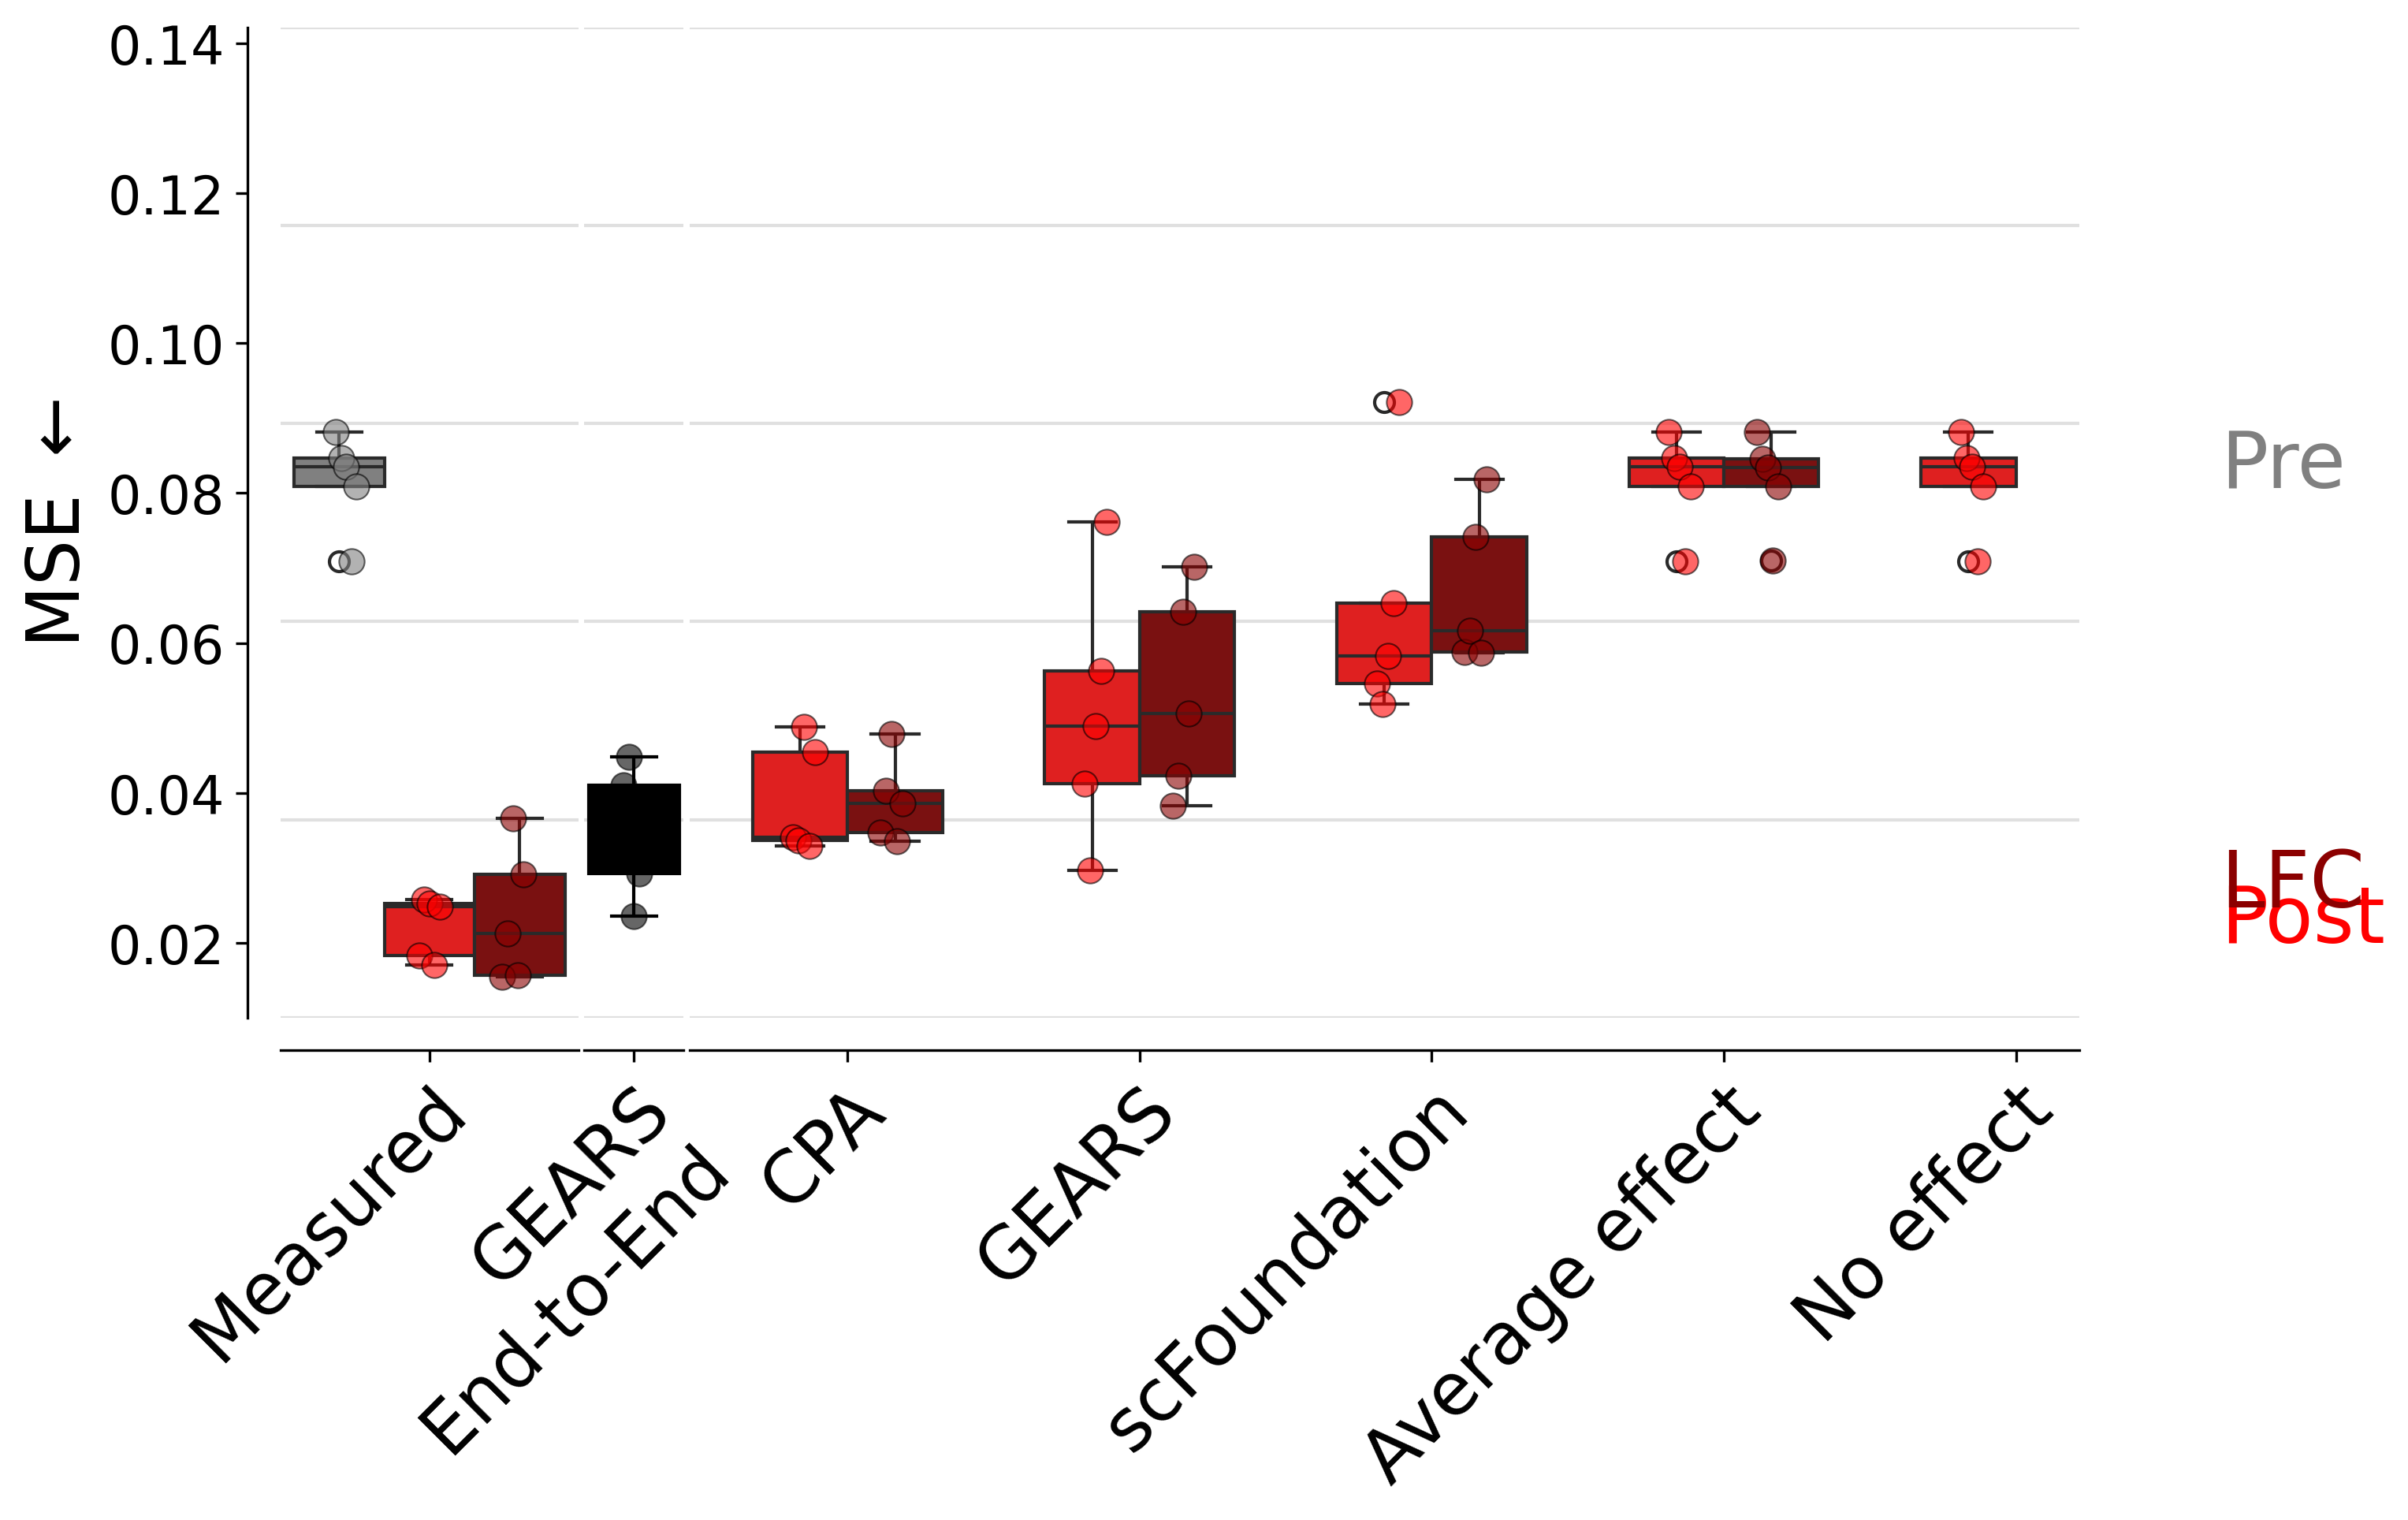

In [12]:
fig, ax= plot_sensitvity_predictions(sciplex_mse_results, metric='mse', plot_text=True, plot_end_to_end=True, plot_legend=False)
fig.savefig(os.path.join(figures_dir,'sciplex_predictions_with_predicted_profiles_mse.pdf'), bbox_inches='tight')
plt.show()

In [13]:
def top_k_percent_overlap(pred, true, percent=10):
    """Compute overlap in the top k% (default 10%) between pred and true (both pd.Series)."""
    n = len(true)
    k = max(1, int(np.ceil(percent / 100 * n)))
    top_true = true.sort_values(ascending=False).head(k).index
    top_pred = pred.sort_values(ascending=False).head(k).index
    return len(set(top_true).intersection(top_pred)) / k

# Apply top-10% overlap per group
observedtrained_top10p_results = (
    predictions_AUC.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_percent_overlap(g['pred'], g['true'], percent=10)
    }))
    .reset_index()
)

selftrained_top10p_results = (
    selftrained_predictions_AUC.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_percent_overlap(g['pred'], g['true'], percent=10)
    }))
    .reset_index()
)

top10p_results_endtoend = (
    end_to_end_predictions.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_percent_overlap(g['pred'], g['true'], percent=10)
    }))
    .reset_index()
)

sciplex_top10_results = pd.concat([
    observedtrained_top10p_results.assign(trained_on='Measured'),
    selftrained_top10p_results.assign(trained_on='Predicted'),
    top10p_results_endtoend.assign(trained_on='End-to-end')
], ignore_index=True)

sciplex_top10_results['top10_overlap'] = sciplex_top10_results['top10_overlap'] * 100  # Convert to percentage

sciplex_top10_results = sciplex_top10_results.replace({'post_treatment': 'Post', 'pre_treatment':'Pre'}).replace({'observed':'Measured',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized'})
                                                                                                                       

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\2288839922.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\2288839922.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\2288839922.py:31: FutureWarning: DataFrameGroupBy.apply operated on the 

In [14]:
# SciPlex + McFarland retrieval accuracy: combined figure in McFarland section below


## Predictions McFarland

In [15]:
end_to_end_predictions = pd.read_csv(os.path.join(data_dir,'GEARS_end_to_end', 'all_cell_lines_test_fitness.csv'))

In [16]:
end_to_end_predictions = end_to_end_predictions.rename(columns={'test_condition':'test_set','truth':'true', 'fold':'split'}).assign(model='Embedding',train_set='Predicted', test_set='GEARS\nEnd-to-End')

In [17]:
predictions_AUC = pd.read_csv(os.path.join(results_dir, 'mcfarland_CPA_fold_cv_predictions.csv'), index_col=0)
predictions_AUC['train_set'] = np.where(predictions_AUC['profile_source'] == 'observed', 'Measured', 'Predicted')
predictions_AUC = predictions_AUC.rename(columns={'profile_source':'test_set'})

predictions_AUC = pd.concat([predictions_AUC, end_to_end_predictions], ignore_index=True)

In [18]:
mcfarland_pearson_results = compute_pearson(predictions_AUC)
mcfarland_pearson_results['trained_on'] = np.where(mcfarland_pearson_results['test_set'] == 'Measured', 'Measured', 'Predicted')

mcfarland_mse_results = compute_mse(predictions_AUC)
mcfarland_mse_results['trained_on'] = np.where(mcfarland_mse_results['test_set'] == 'Measured', 'Measured', 'Predicted')


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[0]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_results = predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[1]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\1504645900.py:6: 

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


SciPlex3 dataset: Pre: 0.14920717063358385, Post: 0.7068229482147718, LFC: 0.7007283439750525
McFarland dataset: Pre: 0.05572127929996427, Post: 0.3299974562572635, LFC: 0.44150487617874445


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:303: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  e2e_ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:303: UserWarning: set_ticklabels() s

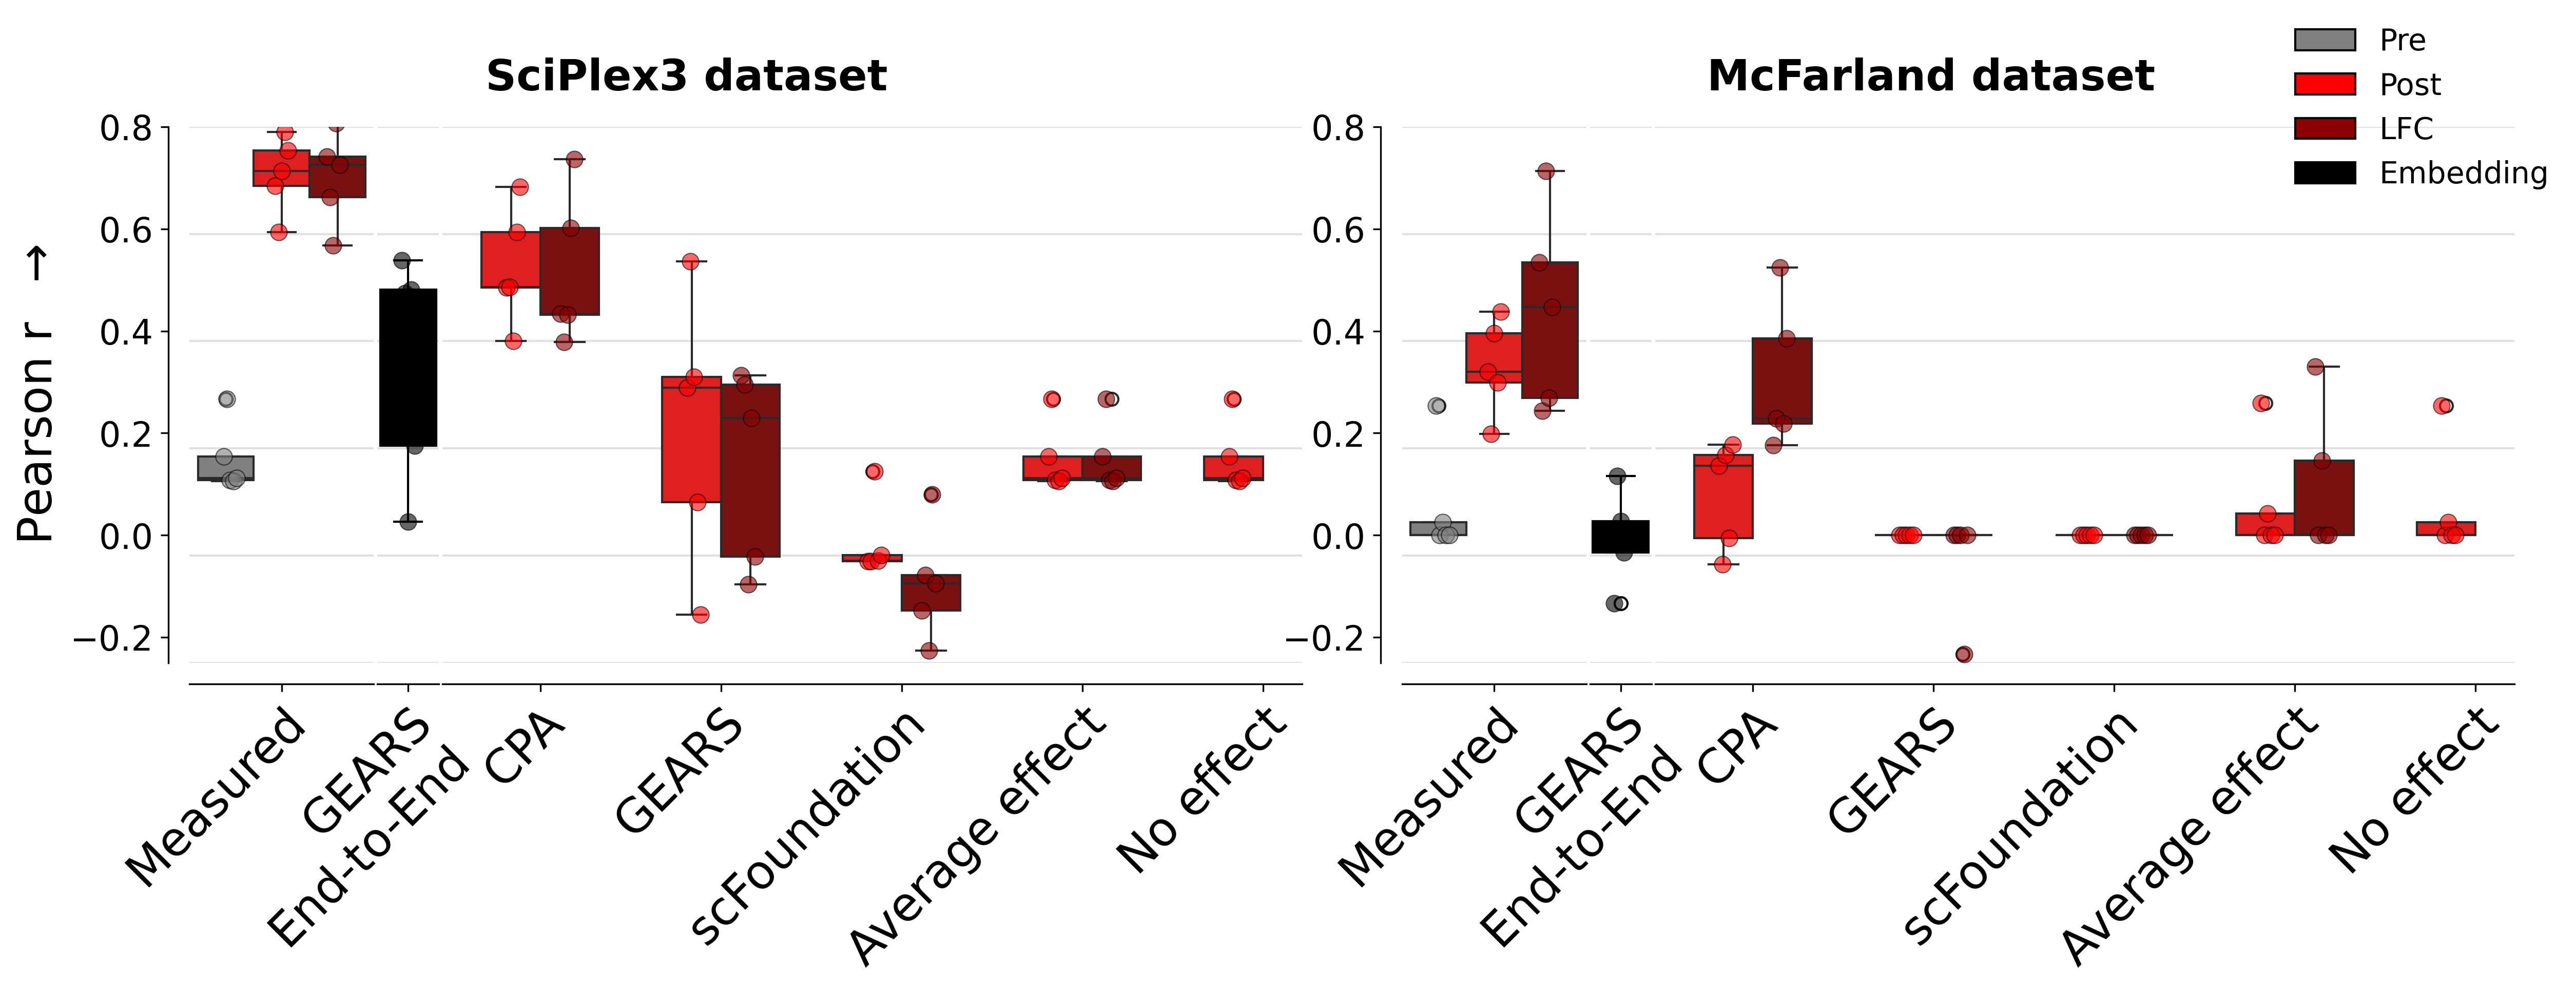

In [19]:
fig, axes = plot_sensitvity_predictions(
    metric='pearson',
    plot_text=False,
    plot_legend=True,
    datasets=[
        {
            'results': sciplex_pearson_results,
            'label': 'SciPlex3 dataset',
            'plot_end_to_end': True,
        },
        {
            'results': mcfarland_pearson_results,
            'label': 'McFarland dataset',
            'plot_end_to_end': True,
        },
    ],
)
fig.savefig(
    os.path.join(figures_dir, 'predictions_with_predicted_profiles_pearson_combined.pdf'),
    bbox_inches='tight',
)
plt.show()

SciPlex3 dataset: Pre: 0.08162191305314292, Post: 0.02224375944511246, LFC: 0.023623633175935254
McFarland dataset: Pre: 0.03253767215466125, Post: 0.029956129469834863, LFC: 0.025651202165009834


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:303: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  e2e_ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() s

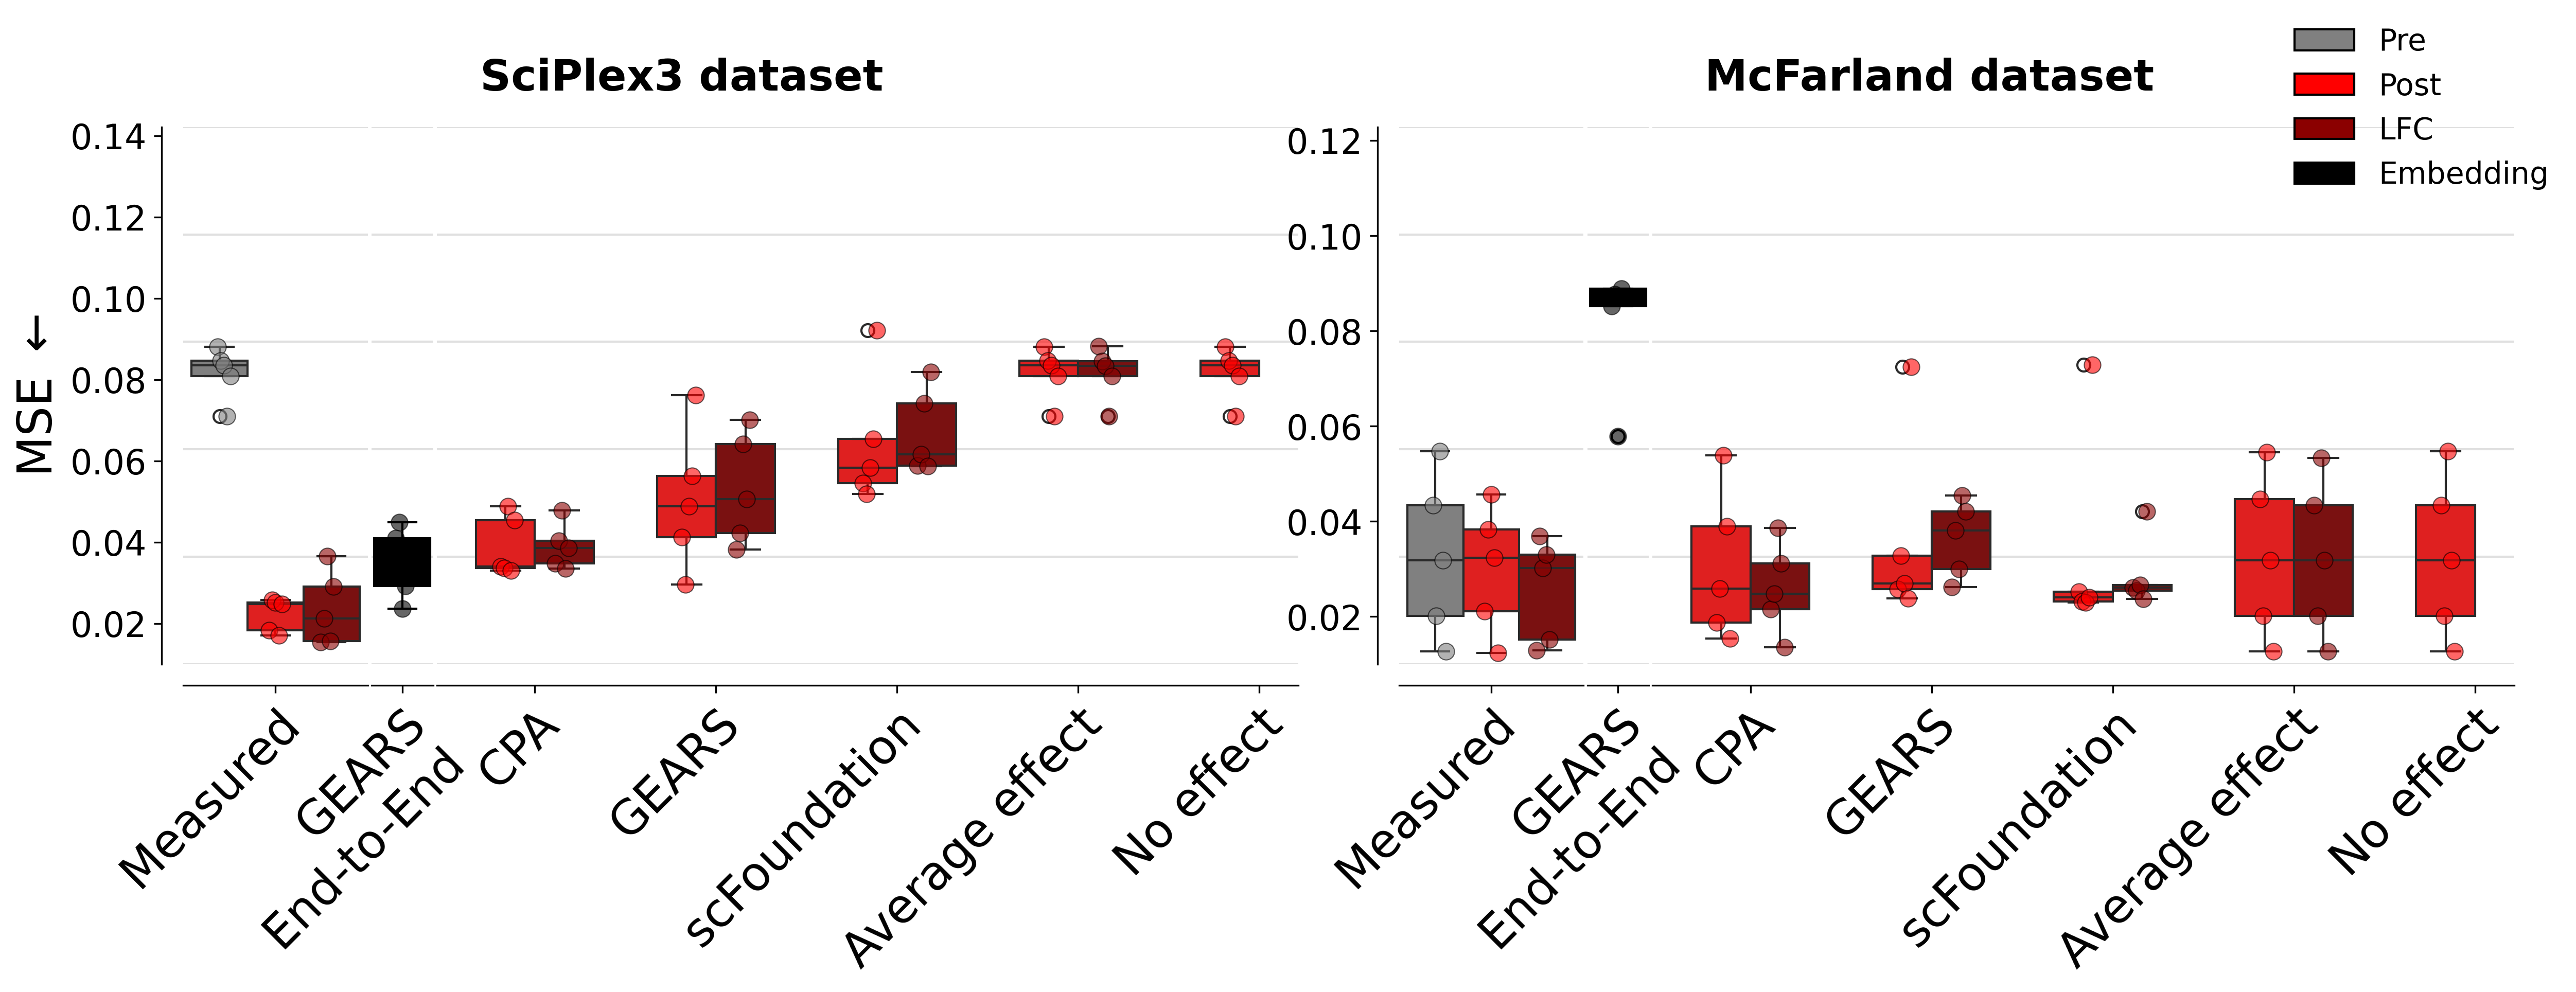

In [20]:
fig, axes = plot_sensitvity_predictions(
    metric='mse',
    plot_text=False,
    plot_legend=True,
    datasets=[
        {
            'results': sciplex_mse_results,
            'label': 'SciPlex3 dataset',
            'plot_end_to_end': True,
        },
        {
            'results': mcfarland_mse_results,
            'label': 'McFarland dataset',
            'plot_end_to_end': True,
        },
    ],
)
fig.savefig(
    os.path.join(figures_dir, 'predictions_with_predicted_profiles_mse_combined.pdf'),
    bbox_inches='tight',
)
plt.show()

In [21]:
def top_k_percent_overlap(pred, true, percent=10):
    """Compute overlap in the top k% (default 10%) between pred and true (both pd.Series)."""
    n = len(true)
    k = max(1, int(np.ceil(percent / 100 * n)))
    top_true = true.sort_values(ascending=False).head(k).index
    top_pred = pred.sort_values(ascending=False).head(k).index
    return len(set(top_true).intersection(top_pred)) / k

# Apply top-10% overlap per group
mcfarland_top10_results = (
    predictions_AUC.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_percent_overlap(g['pred'], g['true'], percent=10)
    }))
    .reset_index()
)

mcfarland_top10_results['trained_on'] = np.where(mcfarland_top10_results['train_set'] == 'Measured', 'Measured', 'Predicted')

mcfarland_top10_results['top10_overlap'] = mcfarland_top10_results['top10_overlap'] * 100  # Convert to percentage

mcfarland_top10_results = mcfarland_top10_results.replace({'post_treatment': 'Post', 'pre_treatment':'Pre'}).replace({'observed':'Measured',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized',
                                                                                                                            'CPA_predicted':'CPA',
                                                                                                                            'GEARS_predicted':'GEARS',
                                                                                                                            'scFoundation_predicted':'scFoundation',
                                                                                                                            'no_effect': 'No effect',
                                                                                                                            'average_effect': 'Average effect'})
                                                                                                                       

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\4033656338.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:303: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  e2e_ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


SciPlex3 dataset: Pre: 28.0, Post: 64.0, LFC: 60.0
McFarland dataset: Pre: 14.237516869095817, Post: 29.81556455240666, LFC: 26.70715249662618


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_43812\3023225651.py:435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.01)


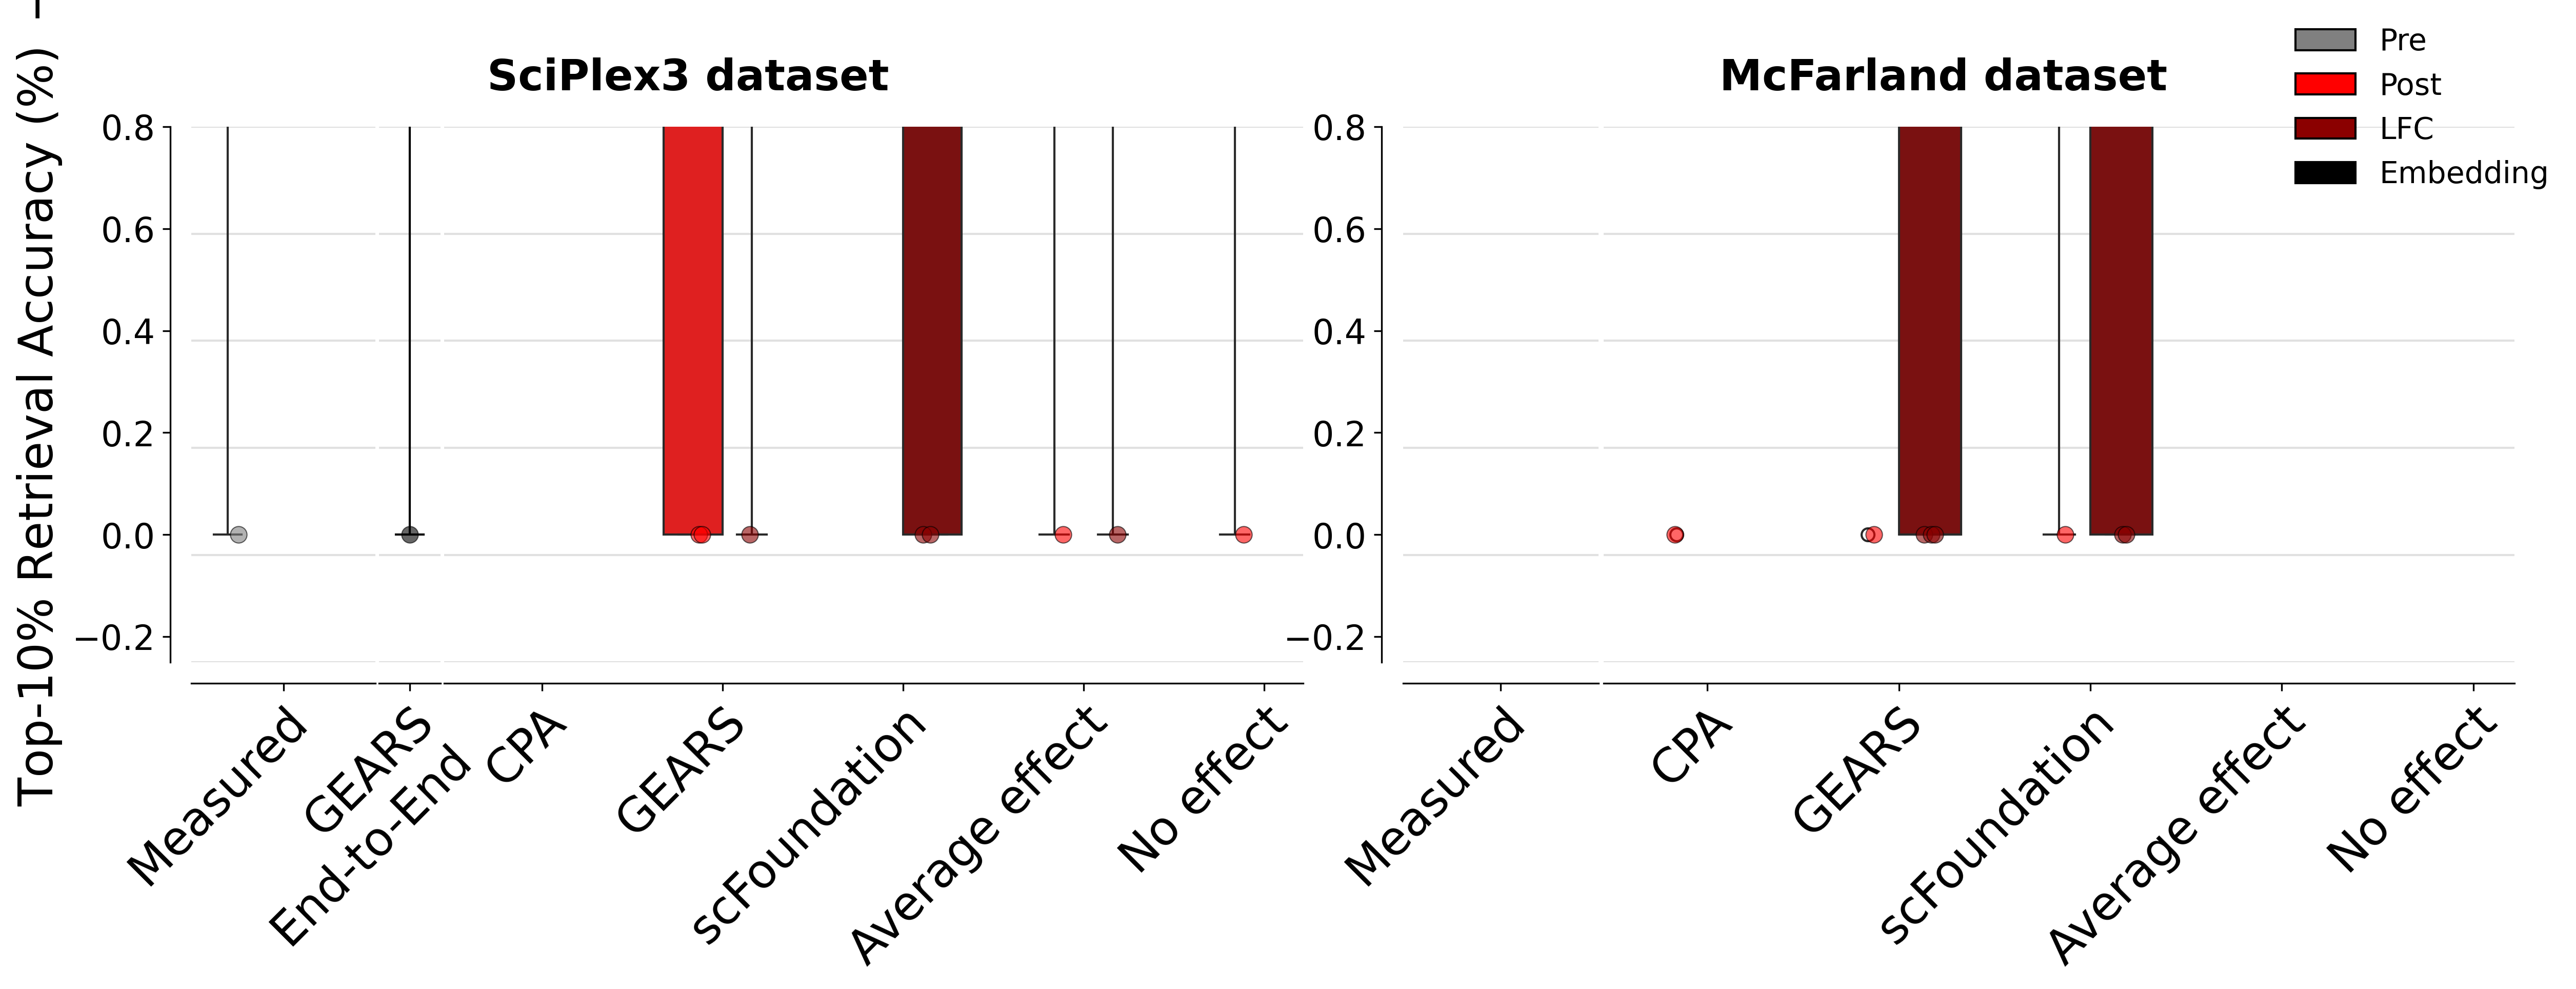

In [22]:
fig, axes = plot_sensitvity_predictions(
    metric='top10_overlap',
    plot_text=False,
    plot_legend=True,
    datasets=[
        {
            'results': sciplex_top10_results,
            'label': 'SciPlex3 dataset',
            'plot_end_to_end': True,
        },
        {
            'results': mcfarland_top10_results,
            'label': 'McFarland dataset',
            'plot_end_to_end': False,
        },
    ],
)
# for ax in axes:
#     ax.axhline(20, ls='--', color='black')
# axes[2].text(x=4.7, y=16, s='Random', color='black', fontsize=24, ha='left')
fig.savefig(
    os.path.join(figures_dir, 'predictions_with_predicted_profiles_retrieval_acc_combined.pdf'),
    bbox_inches='tight',
)
plt.show()